# Week 7 (Day 26) — Live Coding 01
## Transfer Learning Showdown: ResNet vs EfficientNet (TensorFlow/Keras)
### Other alternative exists such as **PyTorch** and **Jax**

**Dataset:** TFDS `cats_vs_dogs`

In this upgraded notebook, we will:
- build **both** backbones (ResNet50 and EfficientNetB0)
- run **head-only training** + **fine-tuning**
- compare **validation performance** and **training speed**
- visualize learning curves and confusion matrices

> If TensorFlow install fails locally, run this notebook in **Google Colab**.

In [2]:
# Setup
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TF_AVAILABLE = True
try:
    import tensorflow as tf
except Exception as e:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = e

if TF_AVAILABLE:
    from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
    print("TensorFlow:", tf.__version__)
    print("GPU available:", bool(tf.config.list_physical_devices("GPU")))
    SEED = 42
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
else:
    print("TensorFlow is not available in this environment.")
    print(f"Reason: {type(TF_IMPORT_ERROR).__name__}: {TF_IMPORT_ERROR}")
    print("Tip: run this notebook in Google Colab (recommended for Week 7 transfer learning).")

TensorFlow: 2.19.0
GPU available: True


## Load data (TFDS cats_vs_dogs)

We build a train/validation/test pipeline with:
- image resize
- model-specific preprocessing later (inside model graph)
- batching + prefetching

For live coding speed, you can reduce `MAX_TRAIN_SAMPLES`.

In [ ]:
if not TF_AVAILABLE:
    print("Skipping data pipeline setup because TensorFlow is unavailable.")
else:
    import tensorflow_datasets as tfds

    IMG_SIZE = (160, 160)
    BATCH_SIZE = 32 # 64, 124, 312
 
    AUTOTUNE = tf.data.AUTOTUNE # for optimal performance with tf.data pipelines

    # Optional speed cap for live coding; set None for full split
    MAX_TRAIN_SAMPLES = 6000
    MAX_VAL_SAMPLES = 1500
    MAX_TEST_SAMPLES = 1500

    (train_ds_raw, val_ds_raw, test_ds_raw), ds_info = tfds.load(
        "cats_vs_dogs",
        split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
        as_supervised=True,
        with_info=True,
    )

    print(ds_info)

    def preprocess(image, label):
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        return image, tf.cast(label, tf.int32)

    def prepare(ds, training=False, max_samples=None):
        if max_samples is not None:
            ds = ds.take(max_samples)
        if training:
            ds = ds.shuffle(1500, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
        return ds

    train_ds = prepare(train_ds_raw, training=True, max_samples=MAX_TRAIN_SAMPLES)
    val_ds = prepare(val_ds_raw, training=False, max_samples=MAX_VAL_SAMPLES)
    test_ds = prepare(test_ds_raw, training=False, max_samples=MAX_TEST_SAMPLES)

    print("Pipelines ready.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UBH0BT_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

## Build transfer-learning models (ResNet + EfficientNet)

We create a reusable model builder so both backbones are trained with the same procedure.

In [5]:
if not TF_AVAILABLE:
    print("Skipping model-building utilities because TensorFlow is unavailable.")
else:
    def build_transfer_model(backbone_name="efficientnet", learning_rate=1e-3):
        if backbone_name == "resnet":
            base = tf.keras.applications.ResNet50(
                include_top=False,
                weights="imagenet",
                input_shape=IMG_SIZE + (3,),
            )
            preprocess_input = tf.keras.applications.resnet.preprocess_input
        elif backbone_name == "efficientnet":
            base = tf.keras.applications.EfficientNetB0(
                include_top=False,
                weights="imagenet",
                input_shape=IMG_SIZE + (3,),
            )
            preprocess_input = tf.keras.applications.efficientnet.preprocess_input
        else:
            raise ValueError("backbone_name must be 'resnet' or 'efficientnet'")

        base.trainable = False

        inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,))
        x = tf.keras.layers.Lambda(preprocess_input)(inputs)
        x = base(x, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

        model = tf.keras.Model(inputs, outputs, name=f"{backbone_name}_transfer")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )

        return model, base

    def plot_histories(history_dict, metric="accuracy", title_prefix=""):
        plt.figure(figsize=(8, 4.5))
        for name, hist in history_dict.items():
            plt.plot(hist.history[metric], label=f"{name} train")
            plt.plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{name} val")
        plt.title(f"{title_prefix}{metric.capitalize()} Curves")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


=== Stage 0 + Head-only training: resnet ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Before head-only -> val_acc=0.5713, val_loss=1.0016
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 64s 181ms/step - accuracy: 0.9014 - loss: 0.2277 - val_accuracy: 0.9773 - val_loss: 0.0587
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.9762 - loss: 0.0639 - val_accuracy: 0.9813 - val_loss: 0.0519
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.9793 - loss: 0.0569 - val_accuracy: 0.9827 - val_loss: 0.0491
After head-only  -> val_acc=0.9827, val_loss=0.0491

=== Stage 0 + Head-only training: efficientnet ===
Before head-only -> val_acc=0.5733, val_loss=0.6853
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 297ms/step - accuracy: 0.8919 - loss: 0.2953 - val_accuracy: 0.9840 - val_loss: 0.0677
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - accuracy: 0.9800 - loss: 0.0743 - val_accuracy: 0.9860 - val_loss: 0.0460
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 10

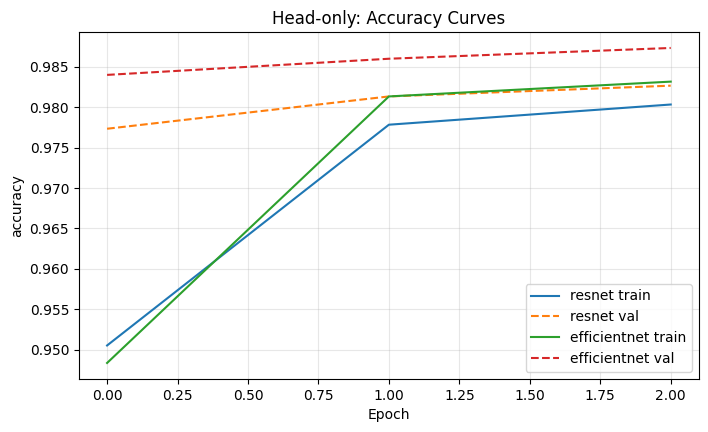

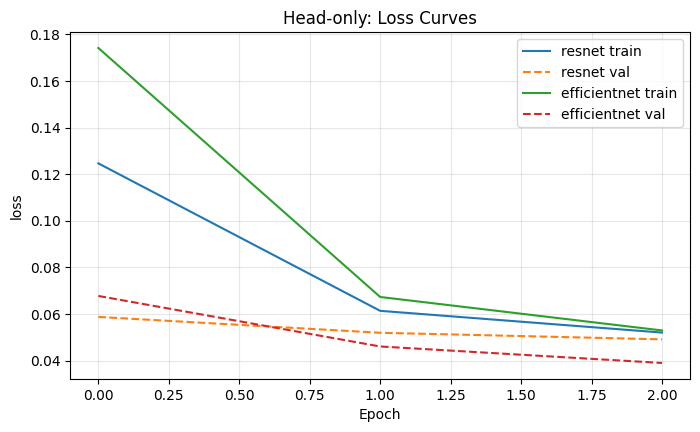

In [ ]:
if not TF_AVAILABLE:
    print("Skipping head-only training because TensorFlow is unavailable.")
else:
    BACKBONES = ["resnet", "efficientnet"]
    HEAD_EPOCHS = 3 # you may change the epoch for more interesting restuls in training loss and accuracy
    FT_EPOCHS = 3 # you may change the epoch for more interesting restuls in training loss and accuracy
    UNFREEZE_LAST = 20

    experiments = {}
    head_histories = {}

    for backbone_name in BACKBONES:
        print(f"\n=== Stage 0 + Head-only training: {backbone_name} ===")
        model, base = build_transfer_model(backbone_name=backbone_name, learning_rate=1e-3) # initial model, base_model and head learning rate can be higher since we're only training the new layers

        # Stage 0: baseline before any head-only training
        pre_loss, pre_acc = model.evaluate(val_ds, verbose=0) # disable verbose to see what's going on during head-only training
        print(f"Before head-only -> val_acc={pre_acc:.4f}, val_loss={pre_loss:.4f}")

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ]


        # Traning model        
        t0 = time.perf_counter()
        hist_head = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=HEAD_EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )
        head_time = time.perf_counter() - t0

        # Stage 1: after head-only training
        head_loss, head_acc = model.evaluate(val_ds, verbose=0)
        print(f"After head-only  -> val_acc={head_acc:.4f}, val_loss={head_loss:.4f}")

        experiments[backbone_name] = {
            "model": model,
            "base": base,
            "head_time_sec": head_time,
            "pre_head_val_loss": float(pre_loss),
            "pre_head_val_acc": float(pre_acc),
            "head_val_loss": float(head_loss),
            "head_val_acc": float(head_acc),
        }
        head_histories[backbone_name] = hist_head

    plot_histories(head_histories, metric="accuracy", title_prefix="Head-only: ")
    plot_histories(head_histories, metric="loss", title_prefix="Head-only: ")

## Stage-wise comparison: Before head-only → After head-only → After fine-tuning

For each backbone, we now compare three checkpoints:
1) **Before head-only** (frozen backbone + random classifier head)
2) **After head-only training**
3) **After fine-tuning**

This makes the contribution of each stage explicit.

In [16]:
count = 0
for i in base.layers:
    # print(i)
    count += 1
print(f"Number of layers in base model: {count}")

Number of layers in base model: 238



=== Fine-tuning: resnet ===
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 87s 253ms/step - accuracy: 0.9709 - loss: 0.0734 - val_accuracy: 0.9780 - val_loss: 0.0498
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - accuracy: 0.9928 - loss: 0.0321 - val_accuracy: 0.9813 - val_loss: 0.0480
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 139ms/step - accuracy: 0.9949 - loss: 0.0232 - val_accuracy: 0.9793 - val_loss: 0.0473

=== Fine-tuning: efficientnet ===
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 136s 484ms/step - accuracy: 0.9622 - loss: 0.1489 - val_accuracy: 0.9887 - val_loss: 0.0505
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9679 - loss: 0.0998 - val_accuracy: 0.9880 - val_loss: 0.0496
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.9720 - loss: 0.0831 - val_accuracy: 0.9893 - val_loss: 0.0438


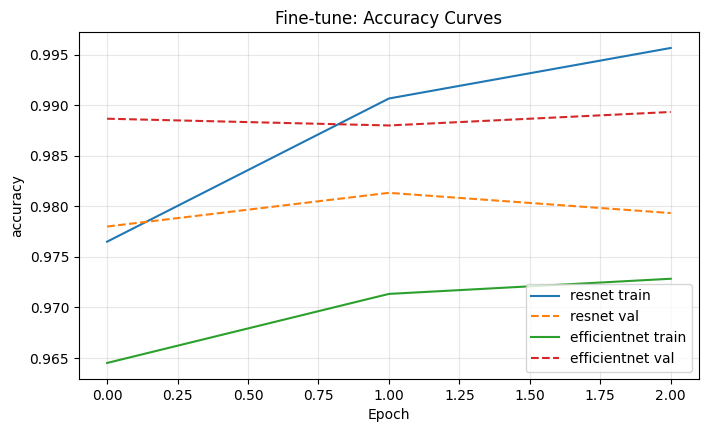

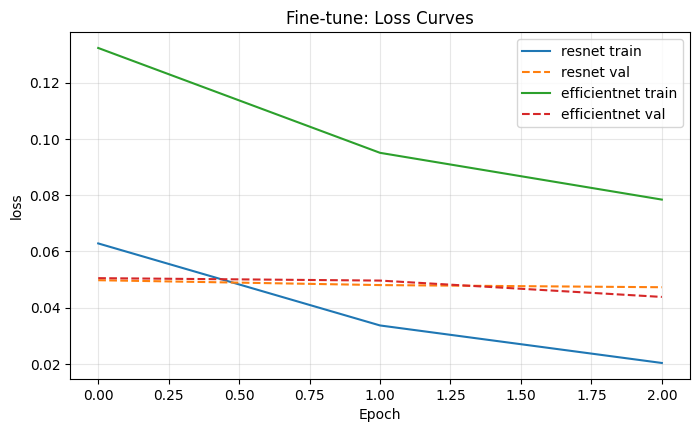


Stage-wise validation summary
    Backbone  Before Head-only Acc  After Head-only Acc  After Fine-tune Acc  Head Gain  Fine-tune Gain  Total Gain  Val Loss  Head Time (s)  Fine-tune Time (s)  Total Time (s)
efficientnet              0.573333             0.987333             0.989333   0.414000        0.002000       0.416  0.043829     131.895088          174.218975      306.114063
      resnet              0.571333             0.982667             0.979333   0.411333       -0.003333       0.408  0.047277     165.258889          169.593465      334.852354


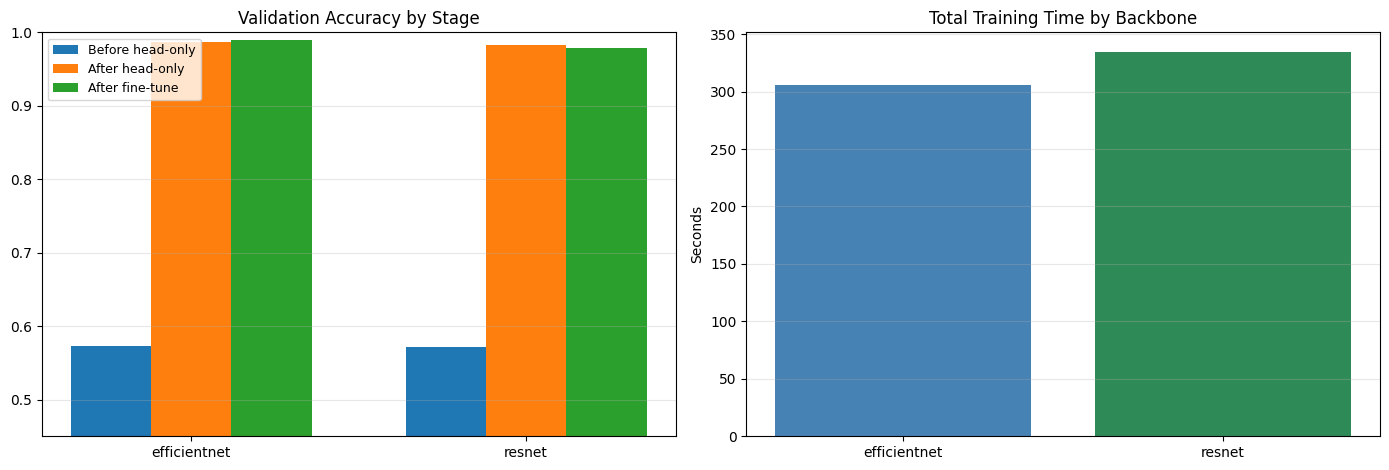


Best backbone by final validation accuracy: efficientnet

Classification report on test set
              precision    recall  f1-score   support

         cat       0.99      0.98      0.98       739
         dog       0.98      0.99      0.98       761

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



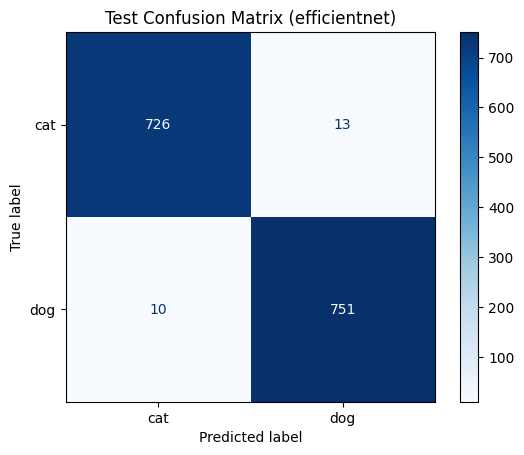

In [ ]:
# We're going modify our backbones models or pretrained

if not TF_AVAILABLE:
    print("Skipping fine-tuning and evaluation because TensorFlow is unavailable.")
else:
    ft_histories = {}
    summary_rows = []

    for backbone_name in BACKBONES:
        print(f"\n=== Fine-tuning: {backbone_name} ===")
        model = experiments[backbone_name]["model"]
        base = experiments[backbone_name]["base"]

        # Unfreeze only top layers
        base.trainable = True
        # UNFREEZE = 20
        # will no freeze the last 20 layers of the base model

        for layer in base.layers[:-UNFREEZE_LAST]: 
            layer.trainable = False

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ]

        t0 = time.perf_counter()
        hist_ft = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=FT_EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )
        ft_time = time.perf_counter() - t0

        # Stage 2: after fine-tuning
        ft_loss, ft_acc = model.evaluate(val_ds, verbose=0)

        experiments[backbone_name]["ft_time_sec"] = float(ft_time)
        experiments[backbone_name]["val_loss"] = float(ft_loss)
        experiments[backbone_name]["val_acc"] = float(ft_acc)
        ft_histories[backbone_name] = hist_ft

        pre_acc = experiments[backbone_name]["pre_head_val_acc"]
        head_acc = experiments[backbone_name]["head_val_acc"]

        summary_rows.append(
            {
                "Backbone": backbone_name,
                "Before Head-only Acc": pre_acc,
                "After Head-only Acc": head_acc,
                "After Fine-tune Acc": float(ft_acc),
                "Head Gain": float(head_acc - pre_acc),
                "Fine-tune Gain": float(ft_acc - head_acc),
                "Total Gain": float(ft_acc - pre_acc),
                "Val Loss": float(ft_loss),
                "Head Time (s)": experiments[backbone_name]["head_time_sec"],
                "Fine-tune Time (s)": float(ft_time),
                "Total Time (s)": experiments[backbone_name]["head_time_sec"] + float(ft_time),
            }
        )

    plot_histories(ft_histories, metric="accuracy", title_prefix="Fine-tune: ")
    plot_histories(ft_histories, metric="loss", title_prefix="Fine-tune: ")

    summary_df = pd.DataFrame(summary_rows).sort_values("After Fine-tune Acc", ascending=False)
    print("\nStage-wise validation summary")
    print(summary_df.to_string(index=False))

    # Stage-wise bars: before -> head-only -> fine-tuned
    x = np.arange(len(summary_df))
    w = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].bar(x - w, summary_df["Before Head-only Acc"], width=w, label="Before head-only")
    axes[0].bar(x, summary_df["After Head-only Acc"], width=w, label="After head-only")
    axes[0].bar(x + w, summary_df["After Fine-tune Acc"], width=w, label="After fine-tune")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary_df["Backbone"])
    axes[0].set_ylim(0.45, 1.0)
    axes[0].set_title("Validation Accuracy by Stage")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend(fontsize=9)

    axes[1].bar(summary_df["Backbone"], summary_df["Total Time (s)"], color=["steelblue", "seagreen"])
    axes[1].set_title("Total Training Time by Backbone")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_backbone = summary_df.iloc[0]["Backbone"]
    best_model = experiments[best_backbone]["model"]
    print(f"\nBest backbone by final validation accuracy: {best_backbone}")

    # Test-set evaluation for best backbone
    y_true = []
    y_prob = []
    for xb, yb in test_ds:
        probs = best_model.predict(xb, verbose=0).ravel()
        y_prob.extend(probs.tolist())
        y_true.extend(yb.numpy().tolist())

    y_true = np.array(y_true)
    y_pred = (np.array(y_prob) >= 0.5).astype(int)

    print("\nClassification report on test set")
    print(classification_report(y_true, y_pred, target_names=["cat", "dog"]))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"]).plot(cmap="Blues")
    plt.title(f"Test Confusion Matrix ({best_backbone})")
    plt.show()